# Classificação Binaria.
Depois de carregar os dados usaremos comprimento e largura da pétala em cm para a classifição.

In [1]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:,2:]
y = (iris.target == 2).astype(np.int)

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state = 7)

# Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression

L = LogisticRegression(penalty ='none', random_state=7)
L.fit(X_train, y_train)

ac_train = L.score(X_train, y_train)
ac_test = L.score(X_test, y_test)

In [4]:
print('Precisão na amostra de treino = %2.3f' % ac_train)
print('Precisão na amostra de teste = %2.3f' % ac_test)

Precisão na amostra de treino = 0.983
Precisão na amostra de teste = 0.867


In [5]:
import matplotlib.pyplot as plt
  
def plot_decision_surface(data, target, classes, class_names, model):
    min1, max1 = data[:, 0].min()-1, data[:, 0].max()+1
    min2, max2 = data[:, 1].min()-1, data[:, 1].max()+1

    x1grid = np.arange(min1, max1, 0.01)
    x2grid = np.arange(min2, max2, 0.01)
    
    xx, yy = np.meshgrid(x1grid, x2grid)
    
    r1, r2 = xx.flatten(), yy.flatten()
    r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))
    
    grid = np.hstack((r1,r2))

    yhat = model.predict(grid)
    zz = yhat.reshape(xx.shape)

    fig = plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, zz, cmap='Paired', alpha=0.75)

    for class_value in range(len(classes)):
      row_ix = np.where(target == class_value)
      plt.scatter(data[row_ix, 0], data[row_ix, 1], label=class_names[class_value], cmap='Paired')
    
    plt.legend(loc='upper left')

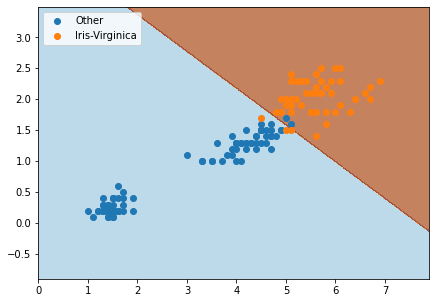

In [6]:
plot_decision_surface(X, y, np.unique(y), ['Other', 'Iris-Virginica'], L)